### **RL Algorithm for Temperature Regulation**

This RL algorithm shows a implementation of an agent for temperature regulation.
It consists of _ main steps:

- **Data fetching**: In this step, we fetch temperature data based on sa server that, given a temperature, returns a regulated one.

- **Finding formula parameters**: As we only know the formula that regulates the temperature, we must know the unknown values of it. For this, we used Least Squared Estimation.

- **Training the Algorithm**: With a way to calculate the next temperature (state) based on the current one, we can implement a RL algorithm.

In [12]:
# Library definition
import numpy as np
import pandas as pd

In [13]:
# Read the dataframe
df = pd.read_csv("datos_temperatura.csv")

# Define our first matrix (m1)
m1 = df[["temperature", "T_target"]].to_numpy()[:-1]
# Define m2 (transposed m1)
m2 = m1.T
# Obtain the temperature Y matrix
Y = df[["temperature"]][1:]

In [14]:
# Print the shape of the matrices
print(f"M1 shape: {m1.shape}")
print(f"M2 shape: {m2.shape}")

M1 shape: (78, 2)
M2 shape: (2, 78)


In [15]:
# Apply the Least Squared Estimation formula
result = np.linalg.inv(m2 @ m1) @ m2 @ Y

In [16]:
# Get the A and B values
A, B = result.values
A = A[0]
B = B[0]
A, B

(0.9304489226191833, 0.06993830626626589)

### **Q-Learning parameters definition**

Now that we've got a way to calculate the next state based on the *state* and *action*

In [17]:
# Define the possible states
states = [i for i in np.arange(20.0, 35.5, .5)]

# Define the possible 
actions = [i for i in range(20, 36)]

# Define the rewards value
rewards = {23.5: 0.5, 24: 5, 24.5: 0.5}

# Define the Q matrix
Q = np.zeros((len(states), len(actions)))
Q.shape

(31, 16)

In [18]:
def round_value(num: float):
    """
    Function to round floating point values
    """
    return round(num * 2) / 2

In [19]:
# Configuración de los parámetros gamma y alfa para el Q-Learning
gamma = 0.75
alpha = 0.9

# Implementación del proceso de Q-Learning
for i in range(5000):
    # Get the states and actions, as well as their indices
    # STATES
    current_state = np.random.choice(states)
    current_state_index = states.index(current_state)
    # ACTIONS
    current_action = np.random.choice(actions)
    current_action_index = actions.index(current_action)
    
    # Calculate the next state based on my formula
    next_state = round_value((A * current_state) + (B * current_action))
    next_state_index = states.index(next_state)
    
    # Get the reward based on the dict of rewards
    Ri = rewards.get(next_state, 0)
    # Calculate TD and apply the result to the Q matrix on the current position
    TD = Ri + gamma*Q[next_state_index, np.argmax(Q[next_state_index,])]- Q[current_state_index, current_action_index]
    Q[current_state_index, current_action_index] = Q[current_state_index, current_action_index] + alpha*TD

In [20]:
# Display the Q-Matrix
for i, row in enumerate(Q):
    print(states[i], " - > ", row)

20.0  - >  [6.31649202 6.312735   6.32474502 6.32438367 6.52841468 6.52813437
 6.52589287 6.52720369 6.51612407 6.50518543 6.5281821  8.43356683
 8.43155498 8.37101716 8.43516328 8.42331954]
20.5  - >  [6.52686561 6.52825099 6.52842052 6.52531088 8.43302533 8.43392789
 8.42032998 8.43261769 8.3920989  8.43512398 8.43109068 8.43156567
 8.70459787 8.70288288 8.70442743 8.7045965 ]
21.0  - >  [ 8.43404541  8.43185101  8.43234939  8.43174847  8.41827598  8.7044335
  8.70202606  8.70459648  8.70453639  8.70294982  8.7043581   8.70454996
 11.24543404 11.24367012 11.24200034 11.24733604]
21.5  - >  [ 8.70442549  8.70456814  8.70457243  8.70256937  8.70198256 11.23246721
 11.23266967 11.23883715 10.8512337  11.24316108 11.24353492 11.23584464
 11.23168445 11.60416398 11.60629538 11.60613085]
22.0  - >  [11.24034389 11.24353419 11.24296153 11.24315102 11.24100422 11.24731156
 11.60632777 11.60602945 11.6005239  11.56129745 11.60577469 11.59365934
 11.60413302 14.97207047 14.98837454 14.99698117

In [24]:
"""
Results Verification
"""
# Set a current state
current_state = 35
print(f"Iteration 0: {current_state:.1f}")
# List to save the current state values
states_values = [current_state]
actions_values = []

i = 1
# Loop over until the state is 24
while current_state != 24:
    # Get the current state index from the rows
    state_idx = states.index(current_state)
    # Get the current action from the row of the state in the Q matrix
    action_index = np.argmax(Q[state_idx])
    
    # Get the current state based on the formula with the data we got from the Q-Matrix
    current_state = round_value((A * current_state) + (B * actions[action_index]))
    states_values.append(current_state)
    actions_values.append(actions[action_index])
    print(f"Iteración {i}: {current_state}")
    i+=1
print("Llegaste a la temperatura deseada.")

Iteration 0: 35.0
Iteración 1: 34.0
Iteración 2: 33.0
Iteración 3: 32.0
Iteración 4: 31.0
Iteración 5: 30.0
Iteración 6: 29.5
Iteración 7: 29.0
Iteración 8: 28.5
Iteración 9: 28.0
Iteración 10: 27.5
Iteración 11: 27.0
Iteración 12: 26.5
Iteración 13: 26.0
Iteración 14: 25.5
Iteración 15: 25.0
Iteración 16: 24.5
Iteración 17: 24.0
Llegaste a la temperatura deseada.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


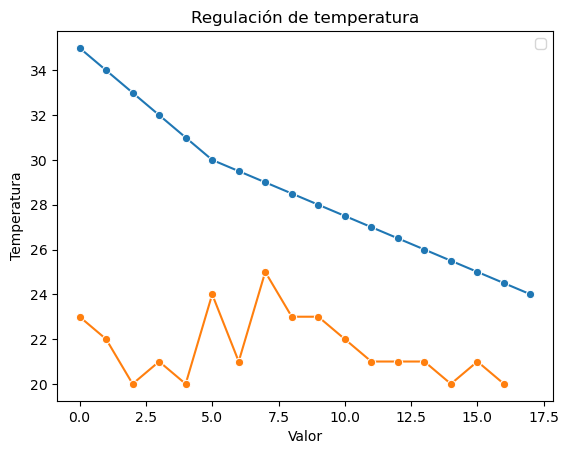

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.title("Regulación de temperatura")
plt.xlabel("Valor")
plt.ylabel("Temperatura")
sns.lineplot(states_values, marker="o")
sns.lineplot(actions_values, marker="o")

plt.legend()